# Визуализация данных: графики для анализа

Сегодня мы переходим от работы с таблицей к **исследовательскому анализу данных**.

Будем работать с реальным датасетом **Palmer Penguins** — измерениями пингвинов разных видов.

Главный вопрос занятия:

> **Какой график выбрать в зависимости от того, что мы хотим узнать о данных?**

Будем разбирать:

- одну категориальную переменную;
- одну числовую переменную;
- две категориальные переменные;
- категориальную + числовую переменную;
- две числовые переменные;
- несколько числовых переменных сразу;
- упорядоченную переменную / время.


## Что нужно уметь после занятия

После занятия важно уметь:

- загрузить данные и быстро понять их структуру;
- сделать простое преобразование столбца;
- использовать строковые методы Pandas;
- отфильтровать данные перед построением графика;
- построить `bar/countplot`;
- построить гистограмму;
- построить boxplot;
- построить scatter plot;
- сравнить числовую переменную между категориями;
- использовать `hue` для дополнительной категории;
- построить корреляционную матрицу;
- выбрать график под исследовательский вопрос;
- написать короткий содержательный вывод по графику.


![DinoUrl](https://www.research.autodesk.com/app/uploads/2023/03/DinoSequential-1.gif)

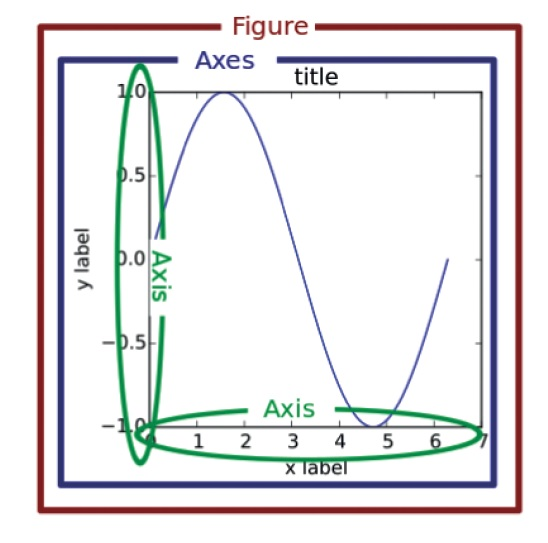

- Figure (Изображение)
- Axes (Область рисования)
- Axis (Координатная ось)
- Artists (элементы рисунка)

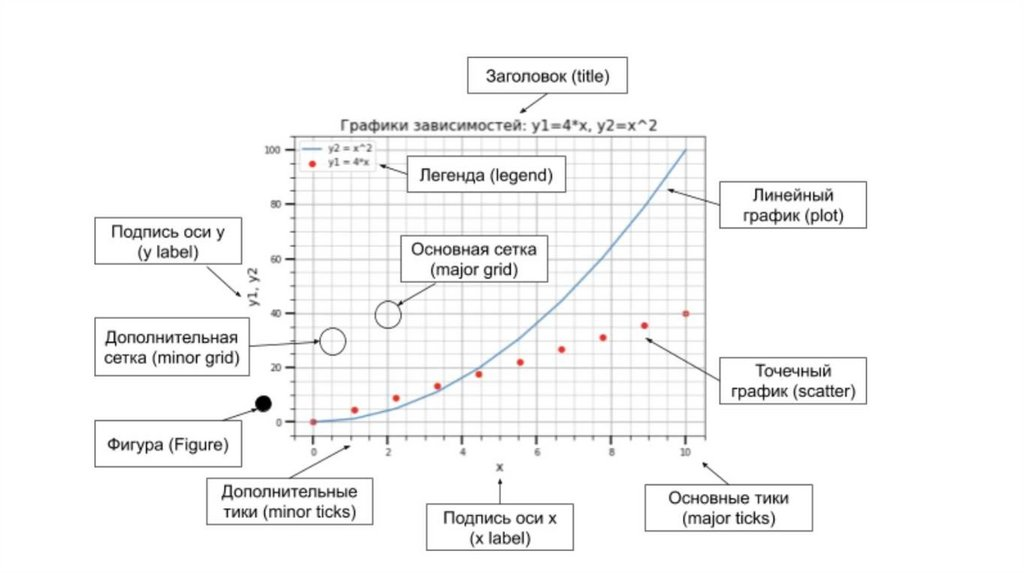

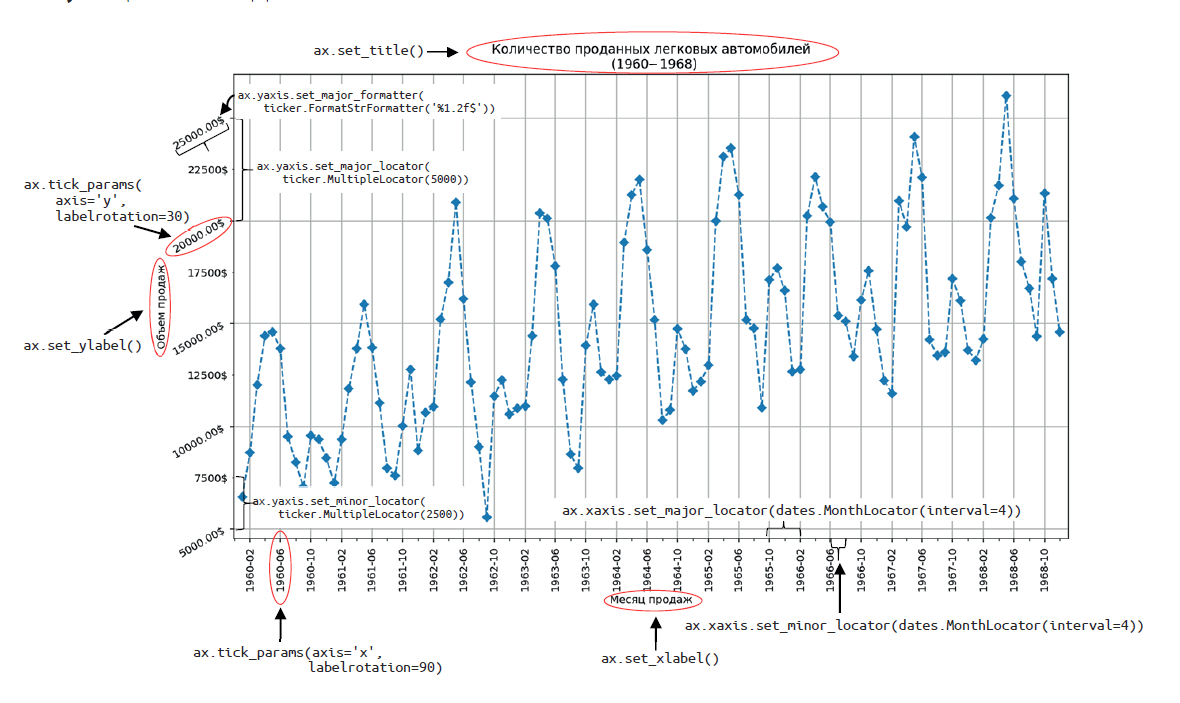

# 1. Загружаем реальный датасет

[palmerpenguins](https://github.com/allisonhorst/palmerpenguins/blob/main/inst/extdata/penguins.csv)

Если вы работаете **локально**, файл `penguins.csv` проще всего положить рядом с ноутбуком:

```python
df = pd.read_csv("penguins.csv")
```

Если вы работаете в **Google Colab**, сначала загрузите файл в текущую сессию:

```python
from google.colab import files

uploaded = files.upload()
```

После этого файл читается обычным `pd.read_csv()`.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("penguins.csv")

df.head()


## Что находится в датасете?

Перед анализом нового датасета полезно разобраться, **что означает каждый столбец**.

Хорошая практика — сделать себе небольшую шпаргалку по данным:  
что хранится в каждом поле, какого оно типа и в каких единицах измеряется.

В `penguins.csv` каждая строка соответствует одному наблюдению за пингвином.

| Столбец | Что означает | Тип данных / единицы |
|---|---|---|
| `species` | вид пингвина | категориальный признак |
| `island` | остров, на котором проводилось наблюдение | категориальный признак |
| `bill_length_mm` | длина клюва | число, мм |
| `bill_depth_mm` | глубина клюва | число, мм |
| `flipper_length_mm` | длина ласта | число, мм |
| `body_mass_g` | масса тела | число, г |
| `sex` | пол пингвина | категориальный признак |
| `year` | год наблюдения | число / временной признак |

В датасете представлены три вида пингвинов:

- `Adelie`;
- `Chinstrap`;
- `Gentoo`.

Наблюдения проводились на трёх островах:

- `Biscoe`;
- `Dream`;
- `Torgersen`.

## 2. Сначала смотрим на таблицу

До построения графиков нужно понять:

- какие есть столбцы;
- какие переменные категориальные;
- какие числовые;
- есть ли пропуски.


In [ ]:
print(df.shape)
print(df.columns)
df.dtypes


In [ ]:
df.info()


In [ ]:
df.isna().sum()


В датасете есть небольшое количество пропусков.

**Сегодня мы их специально не обрабатываем.**

Тема пропусков будет отдельным блоком. При построении большинства графиков Seaborn просто не использует строки, где отсутствует нужное для этого графика значение.


## 3. Какие типы переменных у нас есть?

### Категориальные

- `species` — вид пингвина;
- `island` — остров;
- `sex` — пол.

### Числовые

- `bill_length_mm` — длина клюва;
- `bill_depth_mm` — глубина клюва;
- `flipper_length_mm` — длина ласта;
- `body_mass_g` — масса тела.

### Упорядоченная / временная

- `year` — год наблюдения.

Тип переменной влияет на выбор графика.


# 4. Небольшие преобразования перед анализом

График часто строится не прямо по исходной таблице. Перед ним данные можно преобразовать или отфильтровать.

## Новый числовой столбец

Переведём массу из граммов в килограммы.


In [ ]:
df["body_mass_kg"] = df["body_mass_g"] / 1000

df[["body_mass_g", "body_mass_kg"]].head()


## Строковые методы

Для строкового `Series` используется `.str`.

Например:


In [ ]:
df["species"].str.lower().head()


In [ ]:
df["species"].str.startswith("A").head()


In [ ]:
df[df["species"].str.startswith("A")].head()


Ещё несколько часто встречающихся операций:

```python
df["column"].str.lower()
df["column"].str.upper()
df["column"].str.strip()
df["column"].str.contains("text")
df["column"].str.startswith("A")
df["column"].str.len()
```

Это те же идеи, что у обычных строк Python, но применённые ко всему столбцу.


### Мини-практика 1

1. Создайте столбец `species_lower` с названием вида в нижнем регистре.
2. Выберите строки, где `island` начинается с буквы `B`.
3. Выберите только самок (`sex == "female"`) с массой больше `4 кг`.


In [ ]:
# TODO


# 5. Matplotlib и Seaborn

Для визуализации в Python часто используются обе библиотеки:

- **Matplotlib** — базовая библиотека построения графиков;
- **Seaborn** — более удобный высокоуровневый интерфейс для статистических графиков и работы с `DataFrame`.

Seaborn работает поверх Matplotlib.

В этом курсе мы в основном будем:

- строить аналитические графики через `sns`;
- использовать `plt` для размера, заголовков, подписей осей и оформления.

Один раз построим один и тот же график двумя способами.


## Один график через Matplotlib

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["body_mass_g"].dropna(),
    bins=20,
)

plt.title("Распределение массы пингвинов")
plt.xlabel("Масса, г")
plt.ylabel("Количество")
plt.show()


## Тот же график через Seaborn

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="body_mass_g",
    bins=20,
    color="C0",
)

plt.title("Распределение массы пингвинов")
plt.xlabel("Масса, г")
plt.ylabel("Количество")
plt.show()




Типичная схема в анализе данных:

```python
plt.figure(...)
sns.<график>(...)
plt.title(...)
plt.xlabel(...)
plt.ylabel(...)
plt.show()
```

Seaborn строит аналитический график, а Matplotlib помогает управлять фигурой и оформлением.

Подробно внутреннюю объектную модель Matplotlib сейчас разбирать не нужно.


# 6. Одна категориальная переменная

Исследовательский вопрос:

> Сколько наблюдений каждого вида есть в датасете?

Сначала можно посмотреть таблицу частот:


In [ ]:
df["species"].value_counts()


Для категориальной переменной удобно использовать **столбчатую диаграмму** / `countplot`.


In [ ]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="species", color="C0")

plt.title("Количество наблюдений по видам")
plt.xlabel("Вид")
plt.ylabel("Количество")
plt.show()


### Что смотрим на таком графике?

- какие категории существуют;
- какая встречается чаще;
- есть ли сильный дисбаланс по количеству наблюдений.

Для категорий обычно **не нужен histogram**: категории не образуют непрерывную числовую шкалу.


### Мини-практика 2

Постройте график количества наблюдений по островам (`island`).

После графика ответьте:

> На каком острове наблюдений больше всего?


In [ ]:
# TODO


# 7. Одна числовая переменная: гистограмма

Исследовательский вопрос:

> Как распределена масса пингвинов?

Для числовой переменной один из основных графиков — **гистограмма**.


In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="body_mass_g", bins=20, color="C0")

plt.title("Распределение массы тела")
plt.xlabel("Масса, г")
plt.ylabel("Количество")
plt.show()


## Что такое `bins`?

Числовая ось разбивается на интервалы.

```python
bins=10
bins=20
bins=30
```

могут дать визуально немного разную картину.

Поэтому число `bins` — часть настройки графика, а не свойство данных.


In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="bill_length_mm", bins=25, color="C0")

plt.title("Распределение длины клюва")
plt.xlabel("Длина клюва, мм")
plt.ylabel("Количество")
plt.show()


### Что ищем в распределении?

- где находится основная масса значений;
- насколько велик разброс;
- симметрично ли распределение;
- есть ли несколько выраженных групп;
- есть ли подозрительно редкие крайние значения.


### Мини-практика 3

Постройте гистограмму `flipper_length_mm`.

Попробуйте `bins=10` и `bins=30`.

Ответьте:

> Меняется ли общий вывод о распределении?


In [ ]:
# TODO


# 8. Одна числовая переменная: boxplot

Ещё один важный график для числовой переменной — **boxplot**.

Он компактно показывает:

- медиану;
- центральную часть распределения;
- разброс;
- потенциальные выбросы.


In [ ]:
plt.figure(figsize=(8, 3))

sns.boxplot(data=df, x="body_mass_g")

plt.title("Boxplot массы тела")
plt.xlabel("Масса, г")
plt.show()


Гистограмма и boxplot не конкурируют друг с другом.

Обычно они отвечают на немного разные вопросы:

- histogram лучше показывает **форму распределения**;
- boxplot удобен для **быстрого сравнения разброса и крайних значений**.


### Мини-практика 4

Постройте boxplot для `bill_length_mm`.

Сравните его с гистограммой этой же переменной.


In [ ]:
# TODO


# 9. Категориальная + числовая переменная

Исследовательский вопрос:

> Отличается ли масса тела у разных видов пингвинов?

Здесь одна переменная категориальная (`species`), а другая числовая (`body_mass_g`).

Очень полезен boxplot по категориям.


In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="species", y="body_mass_g")

plt.title("Масса тела по видам")
plt.xlabel("Вид")
plt.ylabel("Масса, г")
plt.show()


Такой график показывает не только одно среднее значение, а распределение внутри каждой категории.

Поэтому для первичного анализа числовой переменной по группам boxplot часто информативнее обычного barplot.


## Дополнительная категория через `hue`

Можно добавить ещё одну категориальную переменную:


In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="species",
    y="body_mass_g",
    hue="sex",
)

plt.title("Масса тела по виду и полу")
plt.xlabel("Вид")
plt.ylabel("Масса, г")
plt.show()


### Мини-практика 5

Постройте boxplot:

- `x="species"`;
- `y="bill_length_mm"`.

Затем добавьте `hue="sex"`.

Сформулируйте 1–2 наблюдения.


In [ ]:
# TODO


# 10. Две числовые переменные: scatter plot

Исследовательский вопрос:

> Связаны ли длина клюва и его глубина?

Для двух числовых переменных один из основных графиков — **scatter plot**.


In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
)

plt.title("Длина и глубина клюва")
plt.xlabel("Длина клюва, мм")
plt.ylabel("Глубина клюва, мм")
plt.show()


По scatter plot можно искать:

- направление связи;
- силу связи;
- отдельные группы;
- необычные наблюдения.


Добавим вид пингвина цветом:


In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
)

plt.title("Параметры клюва по видам")
plt.xlabel("Длина клюва, мм")
plt.ylabel("Глубина клюва, мм")
plt.show()


`hue` часто помогает понять, что видимая структура в двух числовых переменных связана с некоторой категорией.


### Мини-практика 6

Постройте scatter plot:

```text
x = flipper_length_mm
y = body_mass_g
```

Затем добавьте `hue="species"`.

Ответьте:

> Видна ли связь между длиной ласта и массой?


In [ ]:
# TODO


# 11. Две категориальные переменные

Исследовательский вопрос:

> Как распределён пол внутри разных видов?

Один из простых вариантов — `countplot` с `hue`.


In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="species",
    hue="sex",
)

plt.title("Пол пингвинов по видам")
plt.xlabel("Вид")
plt.ylabel("Количество")
plt.show()


Такой график подходит, когда нас интересуют **частоты сочетаний категорий**.


### Мини-практика 7

Постройте `countplot`:

```text
x = island
hue = species
```

Ответьте:

> На всех ли островах встречаются все виды?


In [ ]:
# TODO


# 12. Несколько числовых переменных: корреляционная матрица

Если числовых признаков несколько, можно сначала посчитать корреляции.


In [ ]:
numeric_columns = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

corr = df[numeric_columns].corr()

corr


И визуализировать их как heatmap:


In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

plt.title("Корреляции числовых признаков")
plt.show()


Корреляция:

- близко к `1` — сильная положительная линейная связь;
- близко к `-1` — сильная отрицательная линейная связь;
- близко к `0` — слабая линейная связь.

**Корреляция не доказывает причинно-следственную связь.**

И даже при высокой корреляции полезно посмотреть scatter plot.


### Мини-практика 8

По корреляционной матрице:

1. найдите пару признаков с наиболее сильной положительной корреляцией;
2. постройте для этой пары scatter plot;
3. сравните числовой коэффициент и график.


In [ ]:
# TODO


# 13. Как выбирать график

| Исследовательский вопрос | Тип переменных | Базовый график |
|---|---|---|
| Сколько объектов каждой категории? | 1 категориальная | bar / countplot |
| Как распределена величина? | 1 числовая | histogram |
| Где медиана, разброс, крайние значения? | 1 числовая | boxplot |
| Отличается ли величина между группами? | категория + число | boxplot / barplot |
| Связаны ли две величины? | 2 числовые | scatter plot |
| Как сочетаются две категории? | 2 категориальные | grouped countplot |
| Как связаны несколько числовых признаков? | несколько числовых | correlation heatmap |
| Как показатель меняется во времени? | время + число | line plot |

Это не жёсткие правила, а хорошая отправная точка.


# 14. Что обязательно должно быть у аналитического графика

Минимальный набор:

1. понятный тип графика;
2. осмысленные оси;
3. заголовок;
4. единицы измерения, если они важны;
5. не слишком много категорий / цветов;
6. короткий вывод.

График без интерпретации — ещё не анализ.


# Дополнительно, если успеем

Следующие графики полезны, но не входят в обязательное ядро сегодняшней лекции.


## Barplot: агрегированное значение по категориям

`countplot` отвечает на вопрос **«сколько объектов?»**.

`barplot` с числовой `y` показывает агрегированное числовое значение — по умолчанию среднее.


In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="species",
    y="body_mass_g",
    errorbar=None,
    color="C0",
)

plt.title("Средняя масса тела по видам")
plt.xlabel("Вид")
plt.ylabel("Средняя масса, г")
plt.show()


## Pairplot: быстрый обзор нескольких числовых признаков

Если числовых признаков несколько и хочется быстро посмотреть попарные связи, можно использовать `pairplot`.

Это скорее инструмент быстрого EDA, чем график для итогового отчёта.


In [ ]:
sns.pairplot(
    df[
        [
            "bill_length_mm",
            "bill_depth_mm",
            "flipper_length_mm",
            "body_mass_g",
            "species",
        ]
    ].dropna(),
    hue="species",
)

plt.show()


## Line plot: когда X имеет естественный порядок

Линия имеет смысл, когда по оси X есть естественный порядок — например, время.

В `Palmer Penguins` всего три года, поэтому здесь это только демонстрация принципа.


In [ ]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df,
    x="year",
    y="body_mass_g",
    hue="species",
    estimator="mean",
    errorbar=None,
    marker="o",
)

plt.title("Средняя масса по годам")
plt.xlabel("Год")
plt.ylabel("Средняя масса, г")
plt.show()


# Итоговая практика

Работаем с `df`.

## Шаг 1. Подготовка

1. Создайте `body_mass_kg`.
2. Выберите только строки:
   - `species` — `Adelie` или `Gentoo`;
   - масса известна;
   - пол известен.

Сохраните результат в `df_filtered`.

## Шаг 2. Одномерный анализ

Постройте:

1. `countplot` по `species`;
2. histogram по `body_mass_kg`.

## Шаг 3. Две переменные

Постройте:

1. boxplot массы по видам;
2. scatter plot `flipper_length_mm` vs `body_mass_kg`, цветом обозначьте `species`.

## Шаг 4. Вывод

В Markdown напишите 3–5 предложений:

- чем отличаются выбранные виды;
- что видно по распределению массы;
- есть ли связь массы с длиной ласта.


In [ ]:
# TODO


# Что дальше

Следующий логичный блок — **качество данных**:

- пропуски;
- дубликаты;
- неверные значения;
- выбросы;
- типы данных;
- категориальные признаки.


